# Introducción

**Práctica 2**

Autores:
- Claudia Cuevas Ruano
- Pablo Tejero Lascorz

In [1]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from Datos import Datos
from EstrategiaParticionado import ValidacionSimple
from Estandarizador import Estandarizador
from clasificadores import (
    ClasificadorNaiveBayes,
    ClasificadorKNN,
    ClasificadorRegLog,
    DistanceMetric
)
from clasificadores.sklearn import (
    ClasificadorSklearnKNN,
    ClasificadorSklearnRegLog
)
from clustering import KMeans
from clustering.sklearn import SklearnKMeans

In [2]:
PATH_TO_DATASETS = "../datasets/"


# Datasets sin estandarizar

dataset_wdbc = Datos(PATH_TO_DATASETS + "wdbc.csv")
dataset_fuga = Datos(PATH_TO_DATASETS + "fuga_telefonia.csv")


# Datasets estandarizados

dataset_wdbc_std = Datos(PATH_TO_DATASETS + "wdbc.csv")
dataset_fuga_std = Datos(PATH_TO_DATASETS + "fuga_telefonia.csv")

dataset_wdbc_std.convertir_a_float()
dataset_fuga_std.convertir_a_float()

dataset_wdbc_std.datos.iloc[:,:-1] = Estandarizador(dataset_wdbc_std).estandarizarDatos(dataset_wdbc_std.datos)
dataset_fuga_std.datos.iloc[:,:-1] = Estandarizador(dataset_fuga_std).estandarizarDatos(dataset_fuga_std.datos)

In [3]:
SEED = 33

Deshabilitar algunos warnings de Sklearn:

In [4]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 1 - Regresión Logística

Si bien `ClasificadorSklearnRegLog` emplea el modelo `LogisticRegression` por debajo para la clasificación, cabe señalar que esta implementación muestra diferencias sustanciales con `ClasificadorRegLog`. La versión de Sklearn hace uso de unos *solvers* optimizados que, entre otras cosas, no requieren que se especifique una constante de aprendizaje $\eta$.

In [5]:
reglog_etas = [ 0.001, 0.01, 1 ]
reglog_epochs = [ 1, 100, 450 ]

In [6]:
def reglog_validar(datos: Datos, etas: list[float], epocas: list[int]):
    validador = ValidacionSimple(1, 0.2)

    for eta in etas:
        for n_epochs in epocas:
            clf_pr = ClasificadorRegLog(eta, n_epochs, SEED)
            clf_sk = ClasificadorSklearnRegLog(eta, n_epochs, SEED)

            err_pr = clf_pr.validacion(validador, datos, SEED)
            err_sk = clf_sk.validacion(validador, datos, SEED)

            print(f"Regresion Logistica con {eta=}, {n_epochs=}")
            print(f"  - Error RegLog Propio: {err_pr[0]:.6f}",)
            print(f"  - Error RegLog Scikit: {err_sk[0]:.6f}",)
            print("")

### Regresión Logística para WDBC

In [7]:
reglog_validar(dataset_wdbc, reglog_etas, reglog_epochs)

/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


Regresion Logistica con eta=0.001, n_epochs=1
  - Error RegLog Propio: 0.210526
  - Error RegLog Scikit: 0.631579



/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


Regresion Logistica con eta=0.001, n_epochs=100
  - Error RegLog Propio: 0.078947
  - Error RegLog Scikit: 0.070175



/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


...

/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


Regresion Logistica con eta=0.01, n_epochs=450
  - Error RegLog Propio: 0.096491
  - Error RegLog Scikit: 0.052632

Regresion Logistica con eta=1, n_epochs=1
  - Error RegLog Propio: 0.070175
  - Error RegLog Scikit: 0.631579



/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


Regresion Logistica con eta=1, n_epochs=100
  - Error RegLog Propio: 0.078947
  - Error RegLog Scikit: 0.070175

Regresion Logistica con eta=1, n_epochs=450
  - Error RegLog Propio: 0.078947
  - Error RegLog Scikit: 0.052632



/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


In [8]:
reglog_validar(dataset_wdbc_std, reglog_etas, reglog_epochs)

Regresion Logistica con eta=0.001, n_epochs=1
  - Error RegLog Propio: 0.219298
  - Error RegLog Scikit: 0.061404

Regresion Logistica con eta=0.001, n_epochs=100
  - Error RegLog Propio: 0.017544
  - Error RegLog Scikit: 0.017544

Regresion Logistica con eta=0.001, n_epochs=450
  - Error RegLog Propio: 0.026316
  - Error RegLog Scikit: 0.017544

Regresion Logistica con eta=0.01, n_epochs=1
  - Error RegLog Propio: 0.043860
  - Error RegLog Scikit: 0.061404

Regresion Logistica con eta=0.01, n_epochs=100
  - Error RegLog Propio: 0.035088
  - Error RegLog Scikit: 0.017544

Regresion Logistica con eta=0.01, n_epochs=450
  - Error RegLog Propio: 0.026316
  - Error RegLog Scikit: 0.017544

Regresion Logistica con eta=1, n_epochs=1
  - Error RegLog Propio: 0.017544
  - Error RegLog Scikit: 0.061404

Regresion Logistica con eta=1, n_epochs=100
  - Error RegLog Propio: 0.043860
  - Error RegLog Scikit: 0.017544

Regresion Logistica con eta=1, n_epochs=450
  - Error RegLog Propio: 0.052632
  -

Cabe señalar que la estandarización de los datos no es necesaria cuando se aplica un clasificador de regresión logística. Sin embargo, es preferible hacerlo para evitar problemas de overflow que puedan surgir cuando en el cálculo de la sigmoide se eleva el número $e$ a otro muy grande.

|                            | RegLog Propio | RegLog Sklearn | RegLog Propio (estandarizado) | RegLog Sklearn (estandarizado) |
|:--------------------------:|---------------|----------------|-------------------------------|--------------------------------|
| $\eta=0.001$, epocas=$1$   | 0.2105 | 0.6316 | 0.2193 | 0.0614 |
| $\eta=0.001$, epocas=$100$ | 0.0789 | 0.0702 | 0.0175 | 0.0175 |
| $\eta=0.001$, epocas=$450$ | 0.0789 | 0.0526 | 0.0263 | 0.0175 |
| $\eta=0.01$, epocas=$1$   | 0.0614 | 0.6316 | 0.0438 | 0.0614 |
| $\eta=0.01$, epocas=$100$ | 0.0877 | 0.0702 | 0.0351 | 0.0175 |
| $\eta=0.01$, epocas=$450$ | 0.0965 | 0.0526 | 0.0263 | 0.0175 |
| $\eta=1$, epocas=$1$   | 0.0802 | 0.6316 | 0.0175 | 0.0614 |
| $\eta=1$, epocas=$100$ | 0.0789 | 0.0702 | 0.0438 | 0.0175 |
| $\eta=1$, epocas=$450$ | 0.0789 | 0.0526 | 0.0526 | 0.0175 |

### Regresión Logística para Fuga Telefonía

In [9]:
reglog_validar(dataset_fuga, reglog_etas, reglog_epochs)

Regresion Logistica con eta=0.001, n_epochs=1
  - Error RegLog Propio: 0.445946
  - Error RegLog Scikit: 0.468468



/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:3

Regresion Logistica con eta=0.001, n_epochs=100
  - Error RegLog Propio: 0.382883
  - Error RegLog Scikit: 0.400901



/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


Regresion Logistica con eta=0.001, n_epochs=450
  - Error RegLog Propio: 0.387387
  - Error RegLog Scikit: 0.283784

Regresion Logistica con eta=0.01, n_epochs=1
  - Error RegLog Propio: 0.445946
  - Error RegLog Scikit: 0.468468



...

/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


Regresion Logistica con eta=0.01, n_epochs=450
  - Error RegLog Propio: 0.387387
  - Error RegLog Scikit: 0.283784

Regresion Logistica con eta=1, n_epochs=1
  - Error RegLog Propio: 0.445946
  - Error RegLog Scikit: 0.468468



/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))
/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:36: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 + np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


Regresion Logistica con eta=1, n_epochs=100
  - Error RegLog Propio: 0.382883
  - Error RegLog Scikit: 0.400901

Regresion Logistica con eta=1, n_epochs=450
  - Error RegLog Propio: 0.387387
  - Error RegLog Scikit: 0.283784



/home/pablo/Universidad/Curso4/faa/Practicas/FAA-P0/src/clasificadores/ClasificadorRegLog.py:50: RuntimeWarning: overflow encountered in scalar power
  sigmoide = 1 / (1 +  np.e ** ( -(self.w[0] + np.dot(self.w[1:], attrs)) ))


In [10]:
reglog_validar(dataset_fuga_std, reglog_etas, reglog_epochs)

Regresion Logistica con eta=0.001, n_epochs=1
  - Error RegLog Propio: 0.391892
  - Error RegLog Scikit: 0.337838

Regresion Logistica con eta=0.001, n_epochs=100
  - Error RegLog Propio: 0.306306
  - Error RegLog Scikit: 0.301802

Regresion Logistica con eta=0.001, n_epochs=450
  - Error RegLog Propio: 0.297297
  - Error RegLog Scikit: 0.301802

Regresion Logistica con eta=0.01, n_epochs=1
  - Error RegLog Propio: 0.315315
  - Error RegLog Scikit: 0.337838

Regresion Logistica con eta=0.01, n_epochs=100
  - Error RegLog Propio: 0.301802
  - Error RegLog Scikit: 0.301802

Regresion Logistica con eta=0.01, n_epochs=450
  - Error RegLog Propio: 0.301802
  - Error RegLog Scikit: 0.301802

Regresion Logistica con eta=1, n_epochs=1
  - Error RegLog Propio: 0.405405
  - Error RegLog Scikit: 0.337838

Regresion Logistica con eta=1, n_epochs=100
  - Error RegLog Propio: 0.450450
  - Error RegLog Scikit: 0.301802

Regresion Logistica con eta=1, n_epochs=450
  - Error RegLog Propio: 0.445946
  -

|                            | RegLog Propio | RegLog Sklearn | RegLog Propio (estandarizado) | RegLog Sklearn (estandarizado) |
|:--------------------------:|---------------|----------------|-------------------------------|--------------------------------|
| $\eta=0.001$, epocas=$1$   | 0.3829 | 0.4009 | 0.3919 | 0.3378 |
| $\eta=0.001$, epocas=$100$ | 0.3874 | 0.2837 | 0.3063 | 0.3018 |
| $\eta=0.001$, epocas=$450$ | 0.4459 | 0.4687 | 0.2973 | 0.3018 |
| $\eta=0.01$, epocas=$1$   | 0.3873 | 0.4009 | 0.3153 | 0.3378 |
| $\eta=0.01$, epocas=$100$ | 0.3873 | 0.2837 | 0.3018 | 0.3018 |
| $\eta=0.01$, epocas=$450$ | 0.3829 | 0.4687 | 0.3018 | 0.3018 |
| $\eta=1$, epocas=$1$   | 0.4459 | 0.4685 | 0.4054 | 0.3378 |
| $\eta=1$, epocas=$100$ | 0.3873 | 0.4009 | 0.4505 | 0.3018 |
| $\eta=1$, epocas=$450$ | 0.3874 | 0.2838 | 0.4459 | 0.3018 |

> **NOTA:** Recordemos que el clasificador `LogisticRegression` de sklearn no hace uso de un factor de aprendizaje $\eta$, por lo que los resultados vienen condicionados únicamente por el número de épocas del entrenamiento, de los parámetros utilizados por nosotros.

Dado un factor de aprendizaje fijo, la tendencia muestra una disminución del error proporcional al número de épocas del entrenamiento. Un mayor número de épocas se traduce en una mayor aproximación a la convergencia, por lo que el hiperplano que separa las dos clases es el óptimo.

# 2 - Análisis ROC

In [11]:
roc_clasificadores = (
    #  Name               Classifier                                    ShouldStandarize
    ( "NaiveBayes",       ClasificadorNaiveBayes(),                           False ),
    ( "KNN",              ClasificadorKNN(5, DistanceMetric.EUCLIDES),        True ),
    ( "RegLog",           ClasificadorRegLog(0.001, 100, SEED),               True ),
    ( "KNN (Sklearn)",    ClasificadorSklearnKNN(5, DistanceMetric.EUCLIDES), True ),
    ( "RegLog (Sklearn)", ClasificadorSklearnRegLog(0.001, 100, SEED),        True ),
)

In [12]:
def analisis_roc(dataset_no_std: Datos, dataset_std: Datos, dataset_name: str):
    validador = ValidacionSimple(1, 0.2)

    plot_x = np.ndarray(shape=(len(roc_clasificadores)))
    plot_y = np.ndarray(shape=(len(roc_clasificadores)))

    roc_curve_fpr = []
    roc_curve_tpr = []
    roc_curve_auc = []

    for i, clasificador in enumerate(roc_clasificadores):
        clf = clasificador[1]
        debeEstandarizar = clasificador[2]

        if debeEstandarizar:
            dataset = dataset_std
        else:
            dataset = dataset_no_std


        particion = validador.creaParticiones(dataset, SEED)[0]
        datosTrain = dataset.particion(particion.indicesTrain)
        datosTest  = dataset.particion(particion.indicesTest)

        clases_reales = datosTest.datos.iloc[:,-1]

        clf.entrenamiento(datosTrain)
        predicciones = clf.clasifica(datosTest)

        vp, fp, fn, vn = clf.matriz_confusion(datosTest, predicciones)

        vpr = vp / (vp + fn)
        fpr = fp / (fp + vn)

        plot_x[i] = fpr
        plot_y[i] = vpr

        fpr, tpr, thresholds = roc_curve(clases_reales, predicciones)
        auc = roc_auc_score(clases_reales, predicciones)

        roc_curve_fpr.append(fpr)
        roc_curve_tpr.append(tpr)
        roc_curve_auc.append(auc)

    # Espacio ROC

    ticks = [ n / 10 for n in range(10 + 1) ]
    labels = [ str(n) for n in ticks ]

    fig1, ax1 = plt.subplots()
    ax1.scatter(plot_x, plot_y, marker="o")
    ax1.plot((0, 1), (0, 1), "--", color="red")
    ax1.set_xticks(ticks, labels)
    ax1.set_yticks(ticks, labels)
    ax1.set_title(f"Espacio ROC para {dataset_name}")
    ax1.set_xlabel("Ratio de falsos positivos")
    ax1.set_ylabel("Ratio de verdaderos positivos")
    ax1.grid(True)

    # Etiquetas para cada punto
    texts = []
    for x, y, label in zip(plot_x, plot_y, [clf_dat[0] for clf_dat in roc_clasificadores]):
        texts.append(ax1.text(x, y, label))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', lw=0.5), force_text=2.0)

    fig1.tight_layout()
    fig1.show()

    # Curva ROC
    fig2, axes2 = plt.subplots(nrows=1, ncols=len(roc_clasificadores), figsize=(16, 6))
    axes2: plt.Axes
    for i, ax in enumerate(axes2):
        ax.set_title('ROC')
        ax.plot(roc_curve_fpr[i], roc_curve_tpr[i], "b")
        ax.plot([0, 1], [0, 1], "r--")
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_ylabel('True Positive Rate')
        ax.set_xlabel('False Positive Rate')

    fig2.show()

### Análisis ROC para WDBC

/tmp/ipykernel_8103/303486095.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/tmp/ipykernel_8103/303486095.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


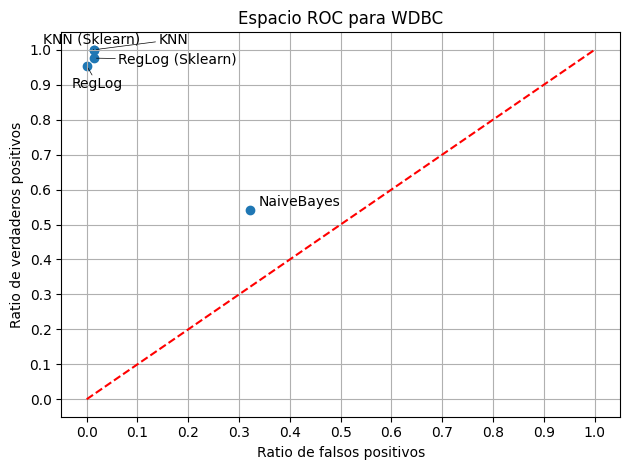

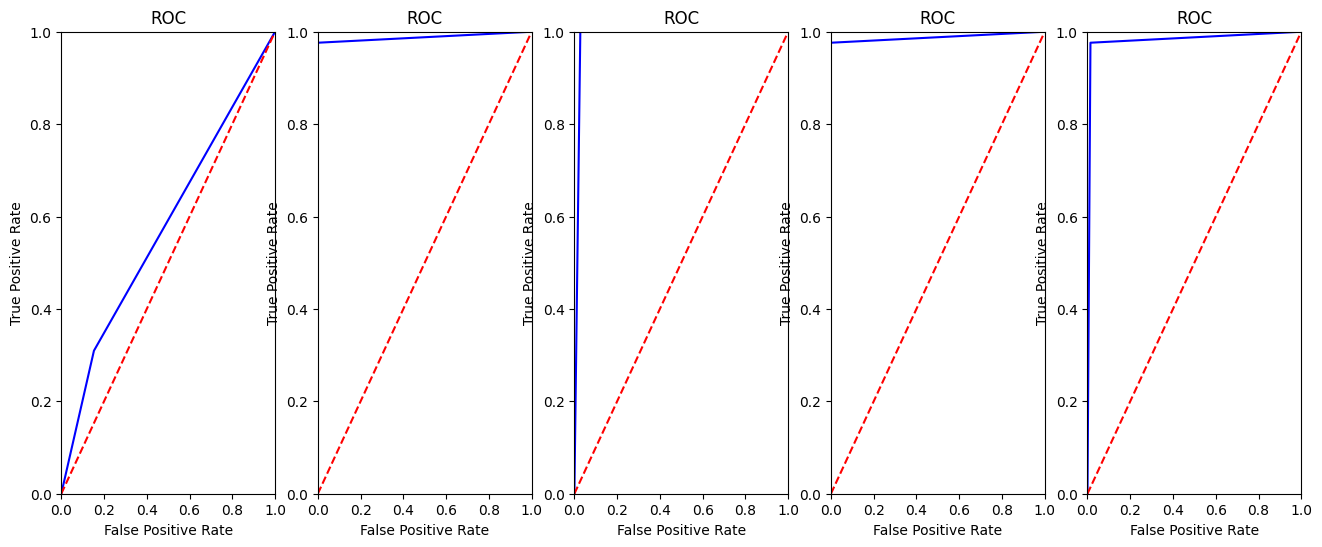

In [13]:
analisis_roc(dataset_wdbc, dataset_wdbc_std, "WDBC")

Se observa que para este dataset todos los modelos a excepción de Naïve-Bayes tienen un ratio similar de verdaderos positivos y no hay uno que sea claramente mejor que otro.

/tmp/ipykernel_8103/303486095.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/tmp/ipykernel_8103/303486095.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


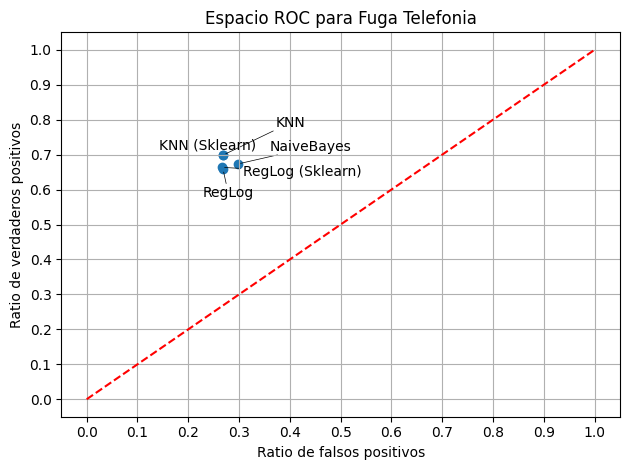

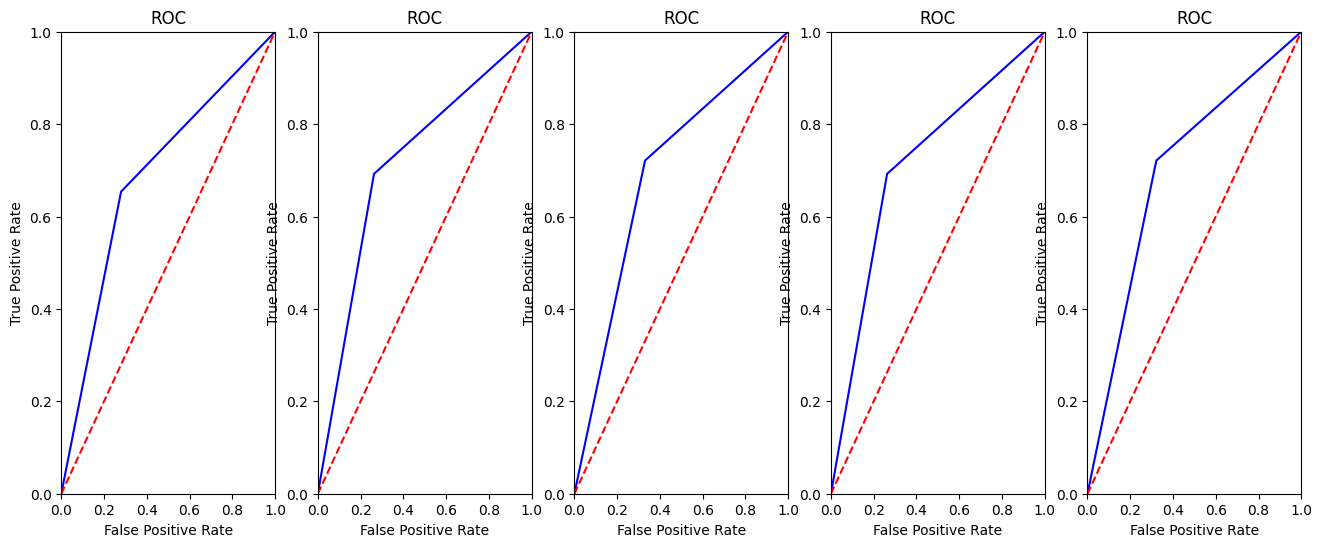

In [14]:
analisis_roc(dataset_fuga, dataset_fuga_std, "Fuga Telefonia")

En contraposición, para fuga telefonía observamos que ningún modelo obtiene tan buenos resultados como con WDBC. Los ratios TPR y FPR son similares para todos.

# 3 - K-means

El algoritmo de K-Means se ha implementando siguiendo los siguientes pasos:
1. Elegir el numero de clusters $k$. Aunque se pueden utilizar herramientas como el método del codo, se han elegido aleatoriamente.
2. Seleccionar aleatoriamente los centroides, que indican dónde está el centro de cada clúster.
3. Se asigna cada punto del cluster al centroide más cercano usando la distancia euclídea.
4. Se evalua la calidad de los clústers (se usa función objetivo).
5. Se recalculan los centroides, dándoles como valor el punto medio entre los datos de cada grupo.
6. Se repiten los pasos 3 y 4 hasta que el algoritmo converga según los pasos establecidos por nosotros:  
    Híper parámetros:  
    * Número de clústers: en cuántos grupos vamos a separar los datos  
    * Número de iteraciones máximas, como criterio de convergencia del algoritmo  
    * Límite de la métrica de evaluación, otro criterio de convergencia

In [15]:
dataset_digitos = Datos(PATH_TO_DATASETS + "digitos.csv")

dataset_digitos.datos.iloc[:,:-1] = Estandarizador(dataset_digitos).estandarizarDatos(dataset_digitos.datos)

attrs = dataset_digitos.datos.iloc[:,:-1]
clases = dataset_digitos.datos.iloc[:,-1]

SEED = 7

In [16]:
from collections import Counter


def estudio_kmeans(tipo_agrupador: KMeans | SklearnKMeans, k: int, attrs: np.ndarray, clases: np.ndarray):

    print("="*60)
    print("K-MEANS CON K =", k)
    print("="*60)

    kmeans = tipo_agrupador(k=k, max_iter=300, limite=0.0001, seed=SEED)
    kmeans.agrupar(attrs.values)

    labels = kmeans.labels
    #Los clusters deben ser diferentes
    unique_clusters = np.unique(labels)
    print(f"Num clusters: {len(unique_clusters)} (valores de {min(unique_clusters)} a {max(unique_clusters)})")
    print("Puntos por cluster:", dict(Counter(labels)))


    print("\n----Distribucion por cluster y clase:----\n")
    tabla = {}
    for c in range (k):
        indices = np.where(labels==c)[0]
        if len(indices) == 0:
            print(f"Cluster {c}: Vacio")
            tabla[c] = Counter()
            continue
        
        clases_cluster = clases.iloc[indices]
        tabla[c] = Counter(clases_cluster)

        #Pureza del cluster
        total = len(clases_cluster)
        if total > 0:
             clase_mayoritaria = tabla[c].most_common(1)[0] #Devuelve una lista con el elemento más frecuente y su conteo
             pureza = clase_mayoritaria[1] / total
             print(f"Cluster {c}:  Pureza: {pureza:.1%}  ->  Muestras por clase: {dict(tabla[c])}")
        else:
            print(f"Cluster {c}: Vacio")
    
    # Mapeo y predicciones
    mapeo_cluster = {}
    for c in range(k):
        #Si un cluster esta vacio
        if len(tabla[c]) == 0:
            mapeo_cluster[c] = None
            continue
        #Obtenemos la clase más frecuente del cluster. 
        mapeo_cluster[c] = tabla[c].most_common(1)[0][0] #Devuelve una lista con el elemento más frecuente y su conteo

    # Asignamos a cada punto la clase mayoritaria de su cluster    
    predicciones = np.array([mapeo_cluster[c] for c in labels])

    # Matriz de confusión
    print("\n----Matriz de confusion----\n")
    matriz = np.zeros((10,10), dtype=int)
    #Llenamos la matriz, siendo la fila la clase real y la columna la predicción
    for clase_real, prediccion in zip(clases, predicciones):
        matriz[int(clase_real)][int(prediccion)] += 1
    
    for i in range(10):
        print(f"{i}: {matriz[i].tolist()}")

    #Calculamos la accuracy
    # Calculamos el porcentaje de predicciones correctas
    acc = np.mean(predicciones == clases.values)
    print(f"\nPorcentaje de pureza total: {acc:.2%}")

    return acc

In [17]:
KMEANS_TEST_K = [8, 10, 12]

resultados = {}
for k in KMEANS_TEST_K:
    resultados[k] = estudio_kmeans(KMeans, k, attrs, clases)

K-MEANS CON K = 8
Num clusters: 8 (valores de 0 a 7)
Puntos por cluster: {np.int64(1): 176, np.int64(2): 458, np.int64(7): 251, np.int64(3): 434, np.int64(0): 190, np.int64(5): 75, np.int64(4): 180, np.int64(6): 33}

----Distribucion por cluster y clase:----

Cluster 0:  Pureza: 93.7%  ->  Muestras por clase: {6: 178, 8: 9, 5: 2, 0: 1}
Cluster 1:  Pureza: 99.4%  ->  Muestras por clase: {0: 175, 6: 1}
Cluster 2:  Pureza: 32.5%  ->  Muestras por clase: {1: 95, 7: 149, 8: 92, 5: 56, 2: 20, 9: 15, 4: 15, 3: 15, 6: 1}
Cluster 3:  Pureza: 35.5%  ->  Muestras por clase: {3: 154, 5: 74, 8: 56, 9: 146, 2: 4}
Cluster 4:  Pureza: 55.0%  ->  Muestras por clase: {5: 47, 2: 99, 3: 13, 8: 12, 1: 1, 7: 8}
Cluster 5:  Pureza: 62.7%  ->  Muestras por clase: {2: 47, 1: 27, 3: 1}
Cluster 6:  Pureza: 54.5%  ->  Muestras por clase: {7: 18, 9: 5, 4: 10}
Cluster 7:  Pureza: 62.2%  ->  Muestras por clase: {2: 7, 4: 156, 1: 59, 7: 4, 9: 14, 8: 5, 5: 3, 0: 2, 6: 1}

----Matriz de confusion----

0: [175, 0, 0, 0,

In [18]:
KMEANS_TEST_K = [8, 10, 12]

resultados = {}
for k in KMEANS_TEST_K:
    resultados[k] = estudio_kmeans(SklearnKMeans, k, attrs, clases)

K-MEANS CON K = 8
Num clusters: 8 (valores de 0 a 7)
Puntos por cluster: {np.int32(2): 178, np.int32(5): 322, np.int32(7): 430, np.int32(4): 237, np.int32(1): 208, np.int32(0): 185, np.int32(3): 206, np.int32(6): 31}

----Distribucion por cluster y clase:----

Cluster 0:  Pureza: 82.7%  ->  Muestras por clase: {7: 153, 3: 7, 9: 9, 4: 9, 5: 2, 2: 2, 8: 3}
Cluster 1:  Pureza: 83.7%  ->  Muestras por clase: {6: 174, 1: 25, 8: 3, 9: 1, 5: 2, 2: 3}
Cluster 2:  Pureza: 98.9%  ->  Muestras por clase: {0: 176, 6: 1, 2: 1}
Cluster 3:  Pureza: 64.6%  ->  Muestras por clase: {2: 133, 5: 43, 3: 11, 1: 2, 8: 11, 7: 6}
Cluster 4:  Pureza: 67.1%  ->  Muestras por clase: {4: 159, 1: 49, 7: 2, 2: 4, 9: 15, 8: 3, 5: 2, 0: 2, 6: 1}
Cluster 5:  Pureza: 32.9%  ->  Muestras por clase: {1: 105, 2: 25, 8: 106, 5: 61, 9: 6, 4: 4, 6: 5, 3: 10}
Cluster 6:  Pureza: 58.1%  ->  Muestras por clase: {7: 18, 9: 4, 4: 9}
Cluster 7:  Pureza: 36.0%  ->  Muestras por clase: {3: 155, 5: 72, 8: 48, 9: 145, 2: 9, 1: 1}

----

### Cuestiones


#### **Cuestión 1:** Para K=10, comprobar si se puede asignar de forma unívoca cada clúster a un dígito atendiendo a la clase mayoritaria de los patrones agrupados por clúster
No, no del todo. Para dígitos como 0, 6, 4 y 7 hay un cluster dedicado a cada uno y la pureza obtenida es muy alta. Sin embargo, para los dígitos 8, 3 y 9 y 11 no sucede lo mismo, pues por ejemplo, el 8 se reparte entre clusters 3, 5, 7 y 8. Son clusters muy mezclados y hacen difícil una asignación unívoca.

#### **Cuestión 2:** Analizar qué tipos de dígitos se identifican más fácilmente y cuales se confunden entre ellos. Para ello se puede hacer uso de la matriz de confusión multiclase a partir del número de puntos en cada clase y sabiendo que hay entre 170 y 185  ejemplos de cada dígito.
- Dígitos muy bien agrupados: 0, 4, 6 y 7. Son de los trazos más simples
- Dígitos medianamente bien identificados: 
    - 1: Aparece mezclado con 7, 8 y 4
    - 2: Se divide en varios clusters
- Dígitos difíciles de separar:
    - 3: Se confunde con 5, 8 y 9
    - 5: Mezclado con 8, 3, 2 y 9
    - 8: Aparece en casi todos los clusters
    - 9: Se mezcla con 3 y 8

#### **Cuestión 3:** Probar con otros valores de K=[8,12] y comparar los resultados con los obtenidos para K=10. ¿Cuál sería el mejor K para este problema? 

**Pureza**                                       

|              | K = 8   | K = 10 | K = 12 | 
|--------------|---------|--------|--------|
| PROPIO       | 54.31%  | 66.17% | 74.07% |
| SKLEARN      | 59.77%  | 59.65% | 67.84% |

**SSE**
|              | K = 8    |  K = 10  | K = 12    |
|--------------|----------|----------|-----------|
| PROPIO       | 74566.85 | 69810.90 | 66159.067 |
| SKLEARN      | 75200.909| 70336.97 | 65966.26  |

### K = 8
Sklearn produce clusters más alineados con las clases, mientras que el algoritmo propio produce clusters más compactos pero peor definidos con respecto a las clases reales. Son muy pocos clusters para 10 dígitos y están muy mezclados. 

### K = 10
El algoritmo propio funciona mejor que el sklearn para este dataset. Produce mejor pureza y mejor SSE. Por otro lado, sklearn empeora ligeramente respecto a K=8

### K = 12
El algoritmo propio obtiene una mayor pureza, aunque el SSE es levemente peor que el obtenido con sklearn. Es el que mejor pureza tiene en ambas implementaciones y permite clusters especializados para variantes. Además, solo hay un dígito problemático.

En conclusión, K=12 es claramente el mejor K ya que obtiene la mejor pureza, la mejor distribución de dígitos y los clústers más puros. 